In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import mplfinance as mpf


In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

OUTDIR = "aapl_charts"
os.makedirs(OUTDIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTDIR, f"{name}.png")
    fig.savefig(path, bbox_inches="tight", dpi=110)
    print(f"  saved -> {path}")

df = pd.read_csv("AAPL_data.csv")
df['Date'] = pd.to_datetime(df["Date"], utc=True)
df = df.set_index("Date").sort_index()

# Indicator-ready subset
dfi = df.dropna(subset=["MA_20", "RSI", "MACD"]).copy()

# Daily returns (aligned to full index)
df["Return"] = df["Close"].pct_change()
df["LogReturn"] = np.log(df["Close"] / df["Close"].shift(1))

# Last N days for readability
N = 250
recent = df.tail(N)
recent_i = dfi.tail(N)

print(f"Rows: {len(df)}  |  Range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Indicator rows: {len(dfi)}\n")


Rows: 2512  |  Range: 2016-09-12 → 2026-09-09
Indicator rows: 2487



In [4]:
def draw_candles(ax, data, width=0.6):
    for date, row in data.iterrows():
        o, h, l, c = row["Open"], row["High"], row["Low"], row["Close"]
        color = "green" if c >= o else "red"
        ax.plot([date, date], [l, h], color=color, linewidth=0.8)
        ax.add_patch(plt.Rectangle(
            (mdates.date2num(date) - width / 2, min(o, c)),
            width, max(abs(c - o), 1e-6),
            facecolor=color, edgecolor=color
        ))


### Price Based Charts

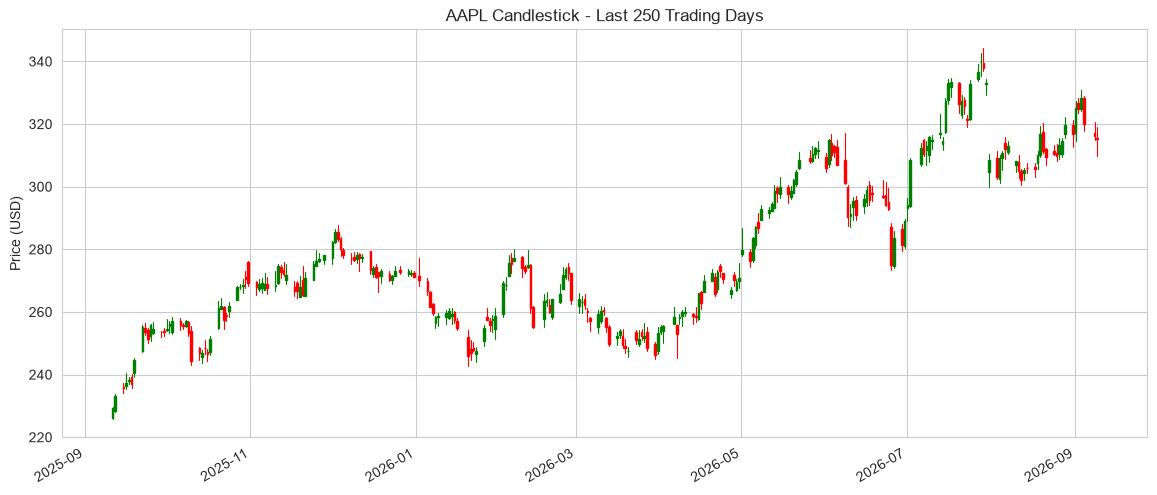

In [ ]:
# Candlestick 

fig, ax = plt.subplots(figsize = (14, 6))
draw_candles(ax, recent)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title(f'AAPL Candlestick - Last {N} Trading Days')
ax.set_ylabel('Price (USD)')
fig.autofmt_xdate()

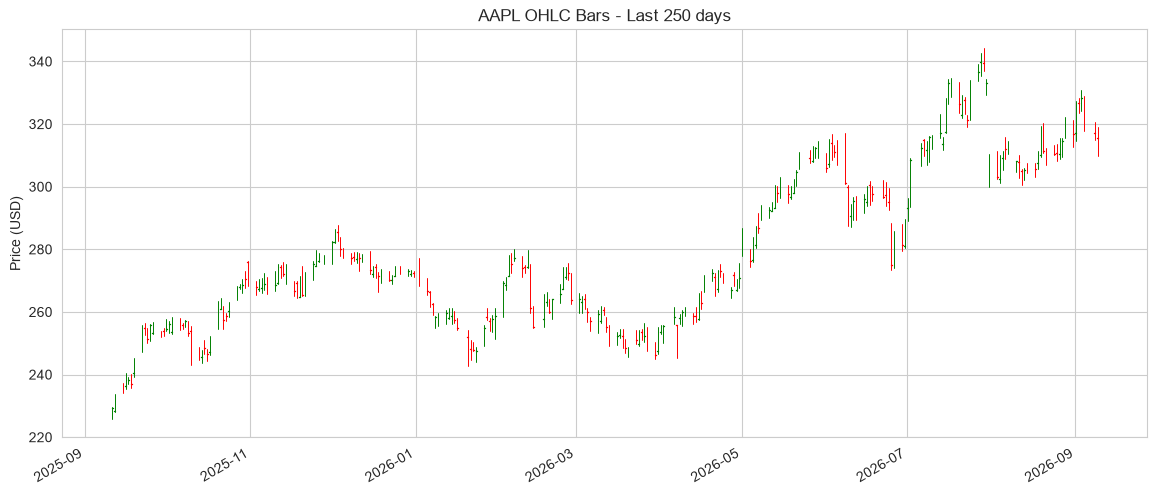

In [7]:
# 2. OHLC bar chart 
fig, ax = plt.subplots(figsize = (14, 6))
for date, row in recent.iterrows():
    color = 'green' if row['Close'] >= row['Open'] else 'red'
    ax.plot([date, date], [row['Low'], row['High']], color = color, linewidth = 0.7)
    ax.plot([date - pd.Timedelta(hours = 4), date], [row['Open'], row['Open']], color = color, linewidth = 1)
    ax.plot([date + pd.Timedelta(hours = 4), date], [row['Close'], row['Close']], color = color, linewidth = 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title(f'AAPL OHLC Bars - Last {N} days')
ax.set_ylabel('Price (USD)')
fig.autofmt_xdate()